# Analyse du benchmark — comparaison modèle vs annotateur expert

Notebook organisé en sections balisées `section:<nom>` pour permettre
l'export HTML sélectif via la dernière section « Exports ».

**Question centrale** : au-delà des désaccords item par item, le modèle
reproduit-il fidèlement les grandeurs agrégées et distributionnelles qui
intéressent la DEPP ?

**Méthode statistique** : IC analytiques (Wilson pour les proportions,
delta method pour le kappa) — instantanés et rigoureux. Le design effect
de Kish est utilisé pour la prévalence par item afin de corriger la
corrélation intra-copie.

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as scistats
from scipy.stats import norm as scinorm
from sklearn.metrics import cohen_kappa_score

from evaluation_dictee.data.reference import load_grid
from evaluation_dictee.evaluation.report import (
    disagreement_decomposition, load_predictions,
    per_copy_metrics, per_item_metrics,
)

# ═════════════════ PARAMÈTRES ═════════════════
RUN_NAME = "dictee_gemma4_cot"
GRID_PATH = "configs/grille_dictee_2015.json"
# ══════════════════════════════════════════════

BASE = Path("..")
PRED = BASE / f"data/processed/{RUN_NAME}_predictions.jsonl"
FIG_DIR = BASE / "data/processed" / f"figures_{RUN_NAME}"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_predictions(PRED)
grid = load_grid(BASE / GRID_PATH)
id_to_mot = {it.item_id: it.attendu for it in grid.items}
id_to_position = {it.item_id: i + 1 for i, it in enumerate(grid.items)}

def lib(item_id: str) -> str:
    return f"{id_to_position.get(item_id, 0):02d} · {id_to_mot.get(item_id, item_id)}"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
C_EXPERT, C_MODELE = "#1f4e79", "#c44536"
C_OK, C_MOYEN, C_PB = "#2e7d32", "#ef6c00", "#c62828"
Z95 = scinorm.ppf(0.975)

print(f"{len(df):,} lignes | {df['copy_id'].nunique()} copies × {df['item_id'].nunique()} items")


118,690 lignes | 1430 copies × 83 items


Note sur les libellés d'items : format `NN · mot`, où `NN` est la position
ordinale dans la dictée. Cela lève l'ambiguïté des mots répétés.

## 1. Synthèse globale avec intervalles de confiance

IC analytiques (Wilson pour les proportions, delta method pour le kappa).
Instantanés et rigoureux — remplace le bootstrap qui souffrait de bugs
silencieux (bornes identiques) sur certaines configurations.

In [21]:
def wilson_global(k, n):
    if n == 0: return float('nan'), float('nan'), float('nan')
    p = k / n
    denom = 1 + Z95**2 / n
    centre = (p + Z95**2 / (2 * n)) / denom
    margin = (Z95 / denom) * (p * (1 - p) / n + Z95**2 / (4 * n**2)) ** 0.5
    return p, max(0.0, centre - margin), min(1.0, centre + margin)

def kappa_ci(y_true, y_pred):
    kappa = cohen_kappa_score(y_true, y_pred)
    n = len(y_true)
    cats = sorted(set(y_true) | set(y_pred))
    cat_idx = {c: i for i, c in enumerate(cats)}
    conf = np.zeros((len(cats), len(cats)))
    for yt, yp in zip(y_true, y_pred):
        conf[cat_idx[yt], cat_idx[yp]] += 1
    conf /= n
    p_e = (conf.sum(axis=0) * conf.sum(axis=1)).sum()
    if p_e == 1.0: return kappa, kappa, kappa
    A = np.diag(conf) * (1 - (conf.sum(axis=0) + conf.sum(axis=1)) * (1 - kappa))
    B = (1 - kappa) ** 2 * (
        (conf * (conf.sum(axis=0)[np.newaxis, :] + conf.sum(axis=1)[:, np.newaxis]) ** 2).sum()
        - np.diag(conf * (conf.sum(axis=0) + conf.sum(axis=1)) ** 2).sum()
    )
    var_k = (A.sum() + B - (kappa - p_e * (1 - kappa)) ** 2) / (n * (1 - p_e) ** 2)
    se = max(0.0, var_k) ** 0.5
    return kappa, kappa - Z95 * se, kappa + Z95 * se

n_total = len(df)
n_accord = int((df['y_true'] == df['y_pred']).sum())
exp_err = df['y_true'] != '1'
mod_err = df['y_pred'] != '1'
n_exp_err, n_mod_err = exp_err.sum(), mod_err.sum()
n_vp = (exp_err & mod_err).sum()

acc, acc_lo, acc_hi = wilson_global(n_accord, n_total)
rap, rap_lo, rap_hi = wilson_global(n_vp, n_exp_err)
pre, pre_lo, pre_hi = wilson_global(n_vp, n_mod_err)
kap, kap_lo, kap_hi = kappa_ci(df['y_true'].values, df['y_pred'].values)

syn = pd.DataFrame([
    {'Métrique': 'Accord brut', 'Valeur': acc, 'IC95 bas': acc_lo, 'IC95 haut': acc_hi},
    {'Métrique': 'Kappa de Cohen', 'Valeur': kap, 'IC95 bas': kap_lo, 'IC95 haut': kap_hi},
    {'Métrique': 'Rappel erreurs (sensibilité)', 'Valeur': rap, 'IC95 bas': rap_lo, 'IC95 haut': rap_hi},
    {'Métrique': 'Précision erreurs', 'Valeur': pre, 'IC95 bas': pre_lo, 'IC95 haut': pre_hi},
]).set_index('Métrique')

print(f"N = {n_total:,} items | {df['copy_id'].nunique()} copies")
display(syn.style.format('{:.1%}'))


N = 118,690 items | 1430 copies


,Valeur,IC95 bas,IC95 haut
Métrique,,,
Accord brut,81.7%,81.5%,82.0%
Kappa de Cohen,48.8%,48.0%,49.6%
Rappel erreurs (sensibilité),60.6%,60.0%,61.2%
Précision erreurs,61.1%,60.5%,61.7%


## 2. Prévalence d'erreur par item — expert vs modèle

**Objectif DEPP** : identifier les items les plus difficiles pour les élèves.
La hiérarchie de difficulté du modèle correspond-elle à celle de l'expert ?

**Méthode** : Wilson corrigé du design effect de Kish (corrélation intra-copie).

In [22]:
def estimate_deff(df, item_col='item_id', label_col='y_true'):
    df2 = df.copy()
    df2['_err'] = (df2[label_col] != '1').astype(float)
    m = df2.groupby('copy_id')[item_col].count().mean()
    var_total = df2['_err'].var(ddof=1)
    if var_total == 0: return 1.0
    copy_means = df2.groupby('copy_id')['_err'].mean()
    var_between = copy_means.var(ddof=1)
    icc = max(0.0, (var_between - (var_total - var_between) / (m - 1)) /
              (var_between + (m - 1) * (var_total - var_between) / (m - 1)))
    return 1 + (m - 1) * icc

deff = max(1.0, estimate_deff(df))
print(f'Design effect estimé : {deff:.3f}')

rows = []
for item_id, grp in df.groupby('item_id'):
    n = len(grp); n_eff = round(n / deff)
    k_exp = int((grp['y_true'] != '1').sum())
    k_mod = int((grp['y_pred'] != '1').sum())
    _, lo_e, hi_e = wilson_global(k_exp, n_eff)
    _, lo_m, hi_m = wilson_global(k_mod, n_eff)
    rows.append({
        'item_id': item_id, 'position': id_to_position.get(item_id, 0),
        'mot_attendu': id_to_mot.get(item_id, item_id),
        'pct_expert': k_exp / n * 100, 'IC_expert_lo': lo_e * 100, 'IC_expert_hi': hi_e * 100,
        'pct_modele': k_mod / n * 100, 'IC_modele_lo': lo_m * 100, 'IC_modele_hi': hi_m * 100,
        'ecart_modele_expert': round((k_mod - k_exp) / n * 100, 2),
    })
prev = pd.DataFrame(rows).set_index('item_id').sort_values('position')

print("\nTop 15 items où le modèle diverge le plus :")
top_div = prev.reindex(prev['ecart_modele_expert'].abs().sort_values(ascending=False).index).head(15)
display(top_div[['position', 'mot_attendu', 'pct_expert', 'pct_modele', 'ecart_modele_expert']]
    .style.format({'pct_expert': '{:.1f} %', 'pct_modele': '{:.1f} %', 'ecart_modele_expert': '{:+.1f} pts'}))

prev.to_csv(BASE / f'data/processed/{RUN_NAME}_prevalence_par_item.csv',
            sep=';', decimal=',', encoding='utf-8-sig')


Design effect estimé : 7.233

Top 15 items où le modèle diverge le plus :


/tmp/ipykernel_538071/3717076658.py:6: RuntimeWarning: invalid value encountered in scalar power
  margin = (Z95 / denom) * (p * (1 - p) / n + Z95**2 / (4 * n**2)) ** 0.5


,position,mot_attendu,pct_expert,pct_modele,ecart_modele_expert
item_id,,,,,
E5FFO154010142,42,",",11.0 %,43.5 %,+32.5 pts
E5FFO154010122,22,-,12.1 %,41.6 %,+29.5 pts
E5FFO154010153,53,-,11.0 %,38.0 %,+27.0 pts
E5FFO154010145,45,verrons,65.4 %,39.9 %,-25.5 pts
E5FFO154010165,65,vus,83.4 %,58.1 %,-25.3 pts
E5FFO154010146,46,arriver,54.7 %,30.1 %,-24.6 pts
E5FFO154010127,27,certainement,53.8 %,30.1 %,-23.8 pts
E5FFO154010174,74,ce,41.5 %,19.7 %,-21.9 pts
E5FFO154010170,70,aussitôt,42.2 %,21.7 %,-20.5 pts


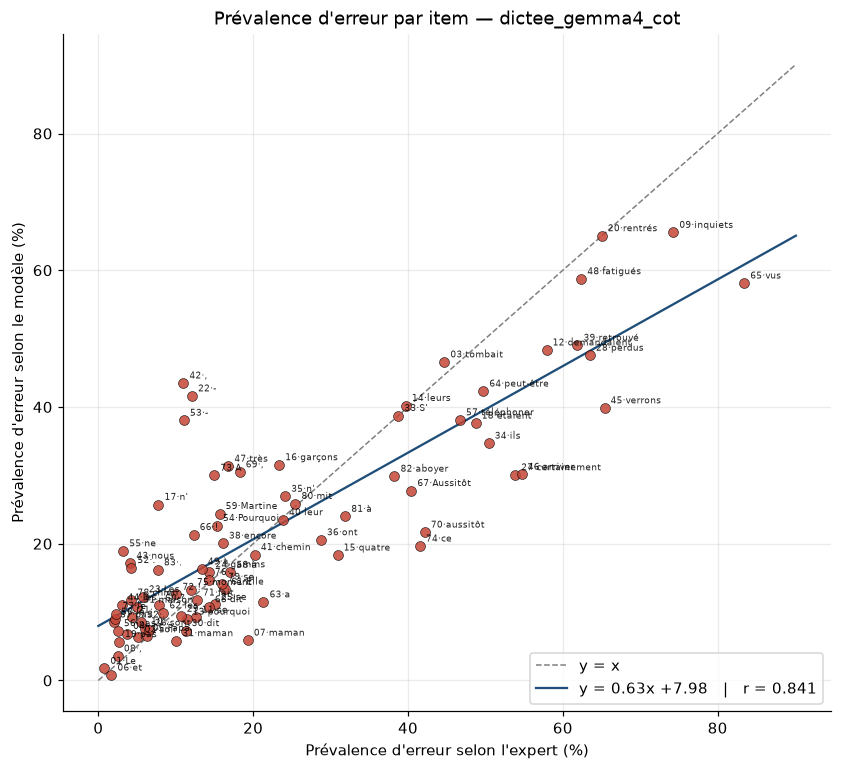

Pearson r=+0.841  |  Spearman ρ=+0.793
Biais moyen : -0.16 pts    Régression : pente=0.633, R²=0.707


In [23]:
fig, ax = plt.subplots(figsize=(9, 8))
x, y = prev['pct_expert'].values, prev['pct_modele'].values
maxv = max(x.max(), y.max()) * 1.08

ax.plot([0, maxv], [0, maxv], color='grey', ls='--', lw=1, label='y = x')
ax.scatter(x, y, s=42, alpha=0.85, color=C_MODELE, edgecolors='k', linewidths=0.4, zorder=3)

slope, intercept, r_value, *_ = scistats.linregress(x, y)
xs = np.array([0, maxv])
ax.plot(xs, intercept + slope * xs, color=C_EXPERT, lw=1.5,
        label=f'y = {slope:.2f}x {intercept:+.2f}   |   r = {r_value:.3f}')

for _, r in prev.iterrows():
    ax.annotate(f"{r['position']:02d}·{r['mot_attendu']}", (r['pct_expert'], r['pct_modele']),
                fontsize=6, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.set_xlabel("Prévalence d'erreur selon l'expert (%)")
ax.set_ylabel("Prévalence d'erreur selon le modèle (%)")
ax.set_title(f"Prévalence d'erreur par item — {RUN_NAME}")
ax.legend(loc='lower right')
plt.savefig(FIG_DIR / '02_prevalence_expert_vs_modele.png')
plt.show()

biais = (y - x).mean()
print(f'Pearson r={np.corrcoef(x, y)[0, 1]:+.3f}  |  Spearman ρ={scistats.spearmanr(x, y).correlation:+.3f}')
print(f'Biais moyen : {biais:+.2f} pts    Régression : pente={slope:.3f}, R²={r_value**2:.3f}')


## 3. Distribution du nombre d'erreurs par copie

Vue en trois panneaux : erreurs totales, fautes seules (code 9), mots
absents (code 0). Complétée d'une courbe de survie qui chiffre la part
de copies au-dessus de chaque seuil.

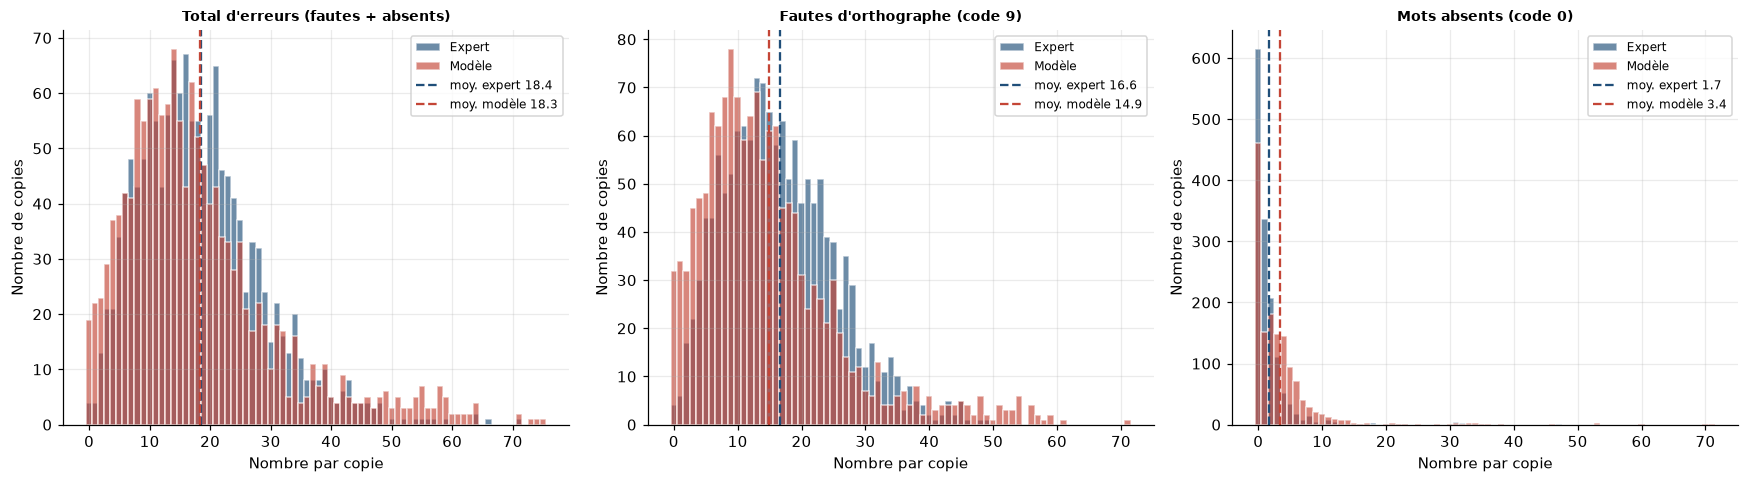

KS (nb total d'erreurs) : D = 0.076, p = 0.00049


,Expert,Modèle
moyenne,18.43,18.3
médiane,17.00,15.0
écart-type,10.18,13.1
q1,11.00,9.0
q3,24.00,23.0
max,71.00,75.0
écart absolu,NaN,NaN


In [24]:
copies_m = per_copy_metrics(df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
COLS = [
    ('n_erreurs_expert', 'n_erreurs_modele', "Total d'erreurs (fautes + absents)"),
    ('n_fautes_expert', 'n_fautes_modele', "Fautes d'orthographe (code 9)"),
    ('n_manquants_expert', 'n_manquants_modele', "Mots absents (code 0)"),
]
for ax, (col_e, col_m, titre) in zip(axes, COLS):
    max_v = max(copies_m[col_e].max(), copies_m[col_m].max())
    bins = np.arange(0, max_v + 2) - 0.5
    ax.hist(copies_m[col_e], bins=bins, alpha=0.65, color=C_EXPERT, label='Expert', edgecolor='white')
    ax.hist(copies_m[col_m], bins=bins, alpha=0.65, color=C_MODELE, label='Modèle', edgecolor='white')
    ax.axvline(copies_m[col_e].mean(), color=C_EXPERT, ls='--', lw=1.5,
               label=f'moy. expert {copies_m[col_e].mean():.1f}')
    ax.axvline(copies_m[col_m].mean(), color=C_MODELE, ls='--', lw=1.5,
               label=f'moy. modèle {copies_m[col_m].mean():.1f}')
    ax.set_xlabel("Nombre par copie"); ax.set_ylabel('Nombre de copies')
    ax.set_title(titre, fontsize=9, fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_distributions.png')
plt.show()

ks = scistats.ks_2samp(copies_m['n_erreurs_expert'], copies_m['n_erreurs_modele'])
print(f"KS (nb total d'erreurs) : D = {ks.statistic:.3f}, p = {ks.pvalue:.3g}")

def stats_col(c):
    return {'moyenne': c.mean(), 'médiane': c.median(), 'écart-type': c.std(),
            'q1': c.quantile(0.25), 'q3': c.quantile(0.75), 'max': c.max()}
comp = pd.DataFrame({'Expert': stats_col(copies_m['n_erreurs_expert']),
                     'Modèle': stats_col(copies_m['n_erreurs_modele'])}).round(2)
comp.loc['écart absolu'] = (comp['Modèle'] - comp['Expert']).round(2)
display(comp)


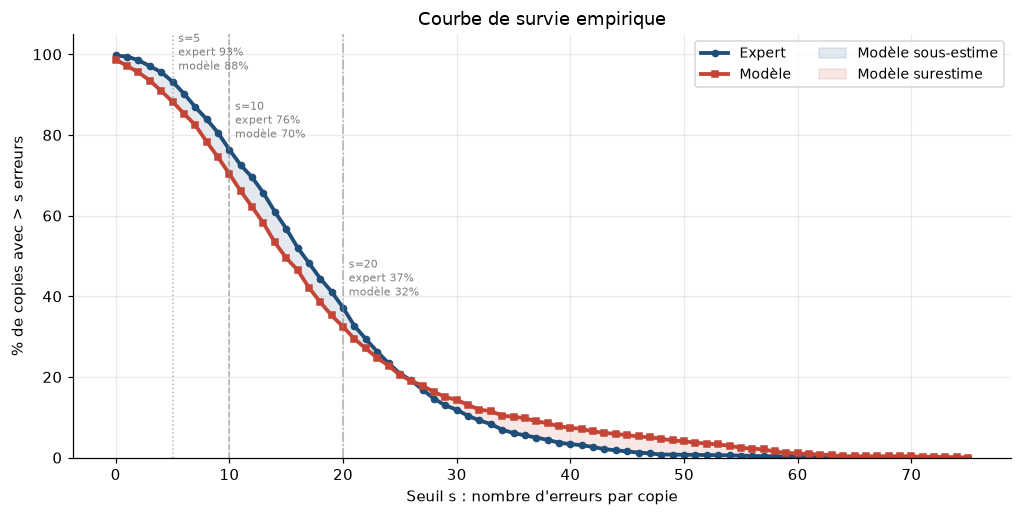

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
max_err = max(copies_m['n_erreurs_expert'].max(), copies_m['n_erreurs_modele'].max())
seuils = np.arange(0, int(max_err) + 1)
surv_exp = [(copies_m['n_erreurs_expert'] > s).mean() * 100 for s in seuils]
surv_mod = [(copies_m['n_erreurs_modele'] > s).mean() * 100 for s in seuils]

ax.plot(seuils, surv_exp, color=C_EXPERT, lw=2.5, marker='o', ms=4, label='Expert')
ax.plot(seuils, surv_mod, color=C_MODELE, lw=2.5, marker='s', ms=4, label='Modèle')
ax.fill_between(seuils, surv_exp, surv_mod,
                where=[e >= m for e, m in zip(surv_exp, surv_mod)],
                alpha=0.12, color=C_EXPERT, label='Modèle sous-estime')
ax.fill_between(seuils, surv_exp, surv_mod,
                where=[m > e for e, m in zip(surv_exp, surv_mod)],
                alpha=0.12, color=C_MODELE, label='Modèle surestime')

for s_ref, ls in [(5, ':'), (10, '--'), (20, '-.')]:
    if s_ref > max_err: continue
    pct_e = (copies_m['n_erreurs_expert'] > s_ref).mean() * 100
    pct_m = (copies_m['n_erreurs_modele'] > s_ref).mean() * 100
    ax.axvline(s_ref, color='grey', ls=ls, lw=1, alpha=0.6)
    ax.annotate(f's={s_ref}\nexpert {pct_e:.0f}%\nmodèle {pct_m:.0f}%',
                xy=(s_ref, max(pct_e, pct_m)), xytext=(s_ref + 0.5, max(pct_e, pct_m) + 3),
                fontsize=7.5, color='grey')

ax.set_xlabel("Seuil s : nombre d'erreurs par copie")
ax.set_ylabel("% de copies avec > s erreurs")
ax.set_title("Courbe de survie empirique"); ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0, 105)
plt.savefig(FIG_DIR / '03b_courbe_survie.png')
plt.show()


## 4. Nombre d'erreurs modèle vs expert par copie

**Objectif DEPP** : le modèle reproduit-il le classement des élèves ?
Une corrélation forte + pente proche de 1 = classement fidèle.

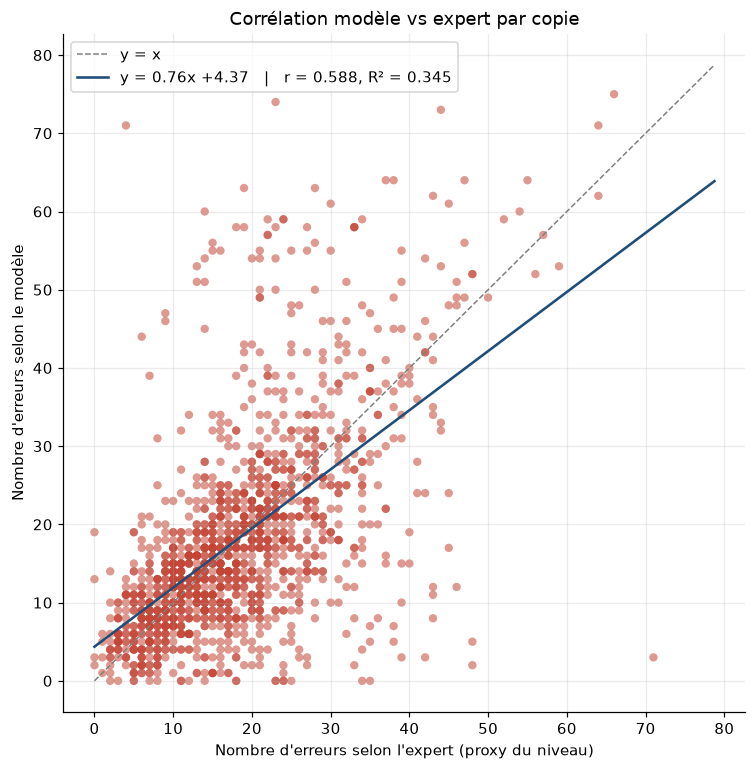

Pearson  r = +0.588  [IC 95 %: +0.532 ; +0.638]
Spearman ρ = +0.605
Kendall  τ = +0.457
Régression : pente = 0.756, R² = 0.345


In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
x = copies_m['n_erreurs_expert'].values
y = copies_m['n_erreurs_modele'].values
maxv = max(x.max(), y.max()) * 1.05

ax.plot([0, maxv], [0, maxv], color='grey', ls='--', lw=1, label='y = x')
ax.scatter(x, y, s=30, alpha=0.55, color=C_MODELE, edgecolors='none')

slope, intercept, r_value, *_ = scistats.linregress(x, y)
xs = np.array([0, maxv])
ax.plot(xs, intercept + slope * xs, color=C_EXPERT, lw=1.7,
        label=f'y = {slope:.2f}x {intercept:+.2f}   |   r = {r_value:.3f}, R² = {r_value**2:.3f}')
ax.set_xlabel("Nombre d'erreurs selon l'expert (proxy du niveau)")
ax.set_ylabel("Nombre d'erreurs selon le modèle")
ax.set_title('Corrélation modèle vs expert par copie')
ax.legend(loc='upper left')
plt.savefig(FIG_DIR / '04_correlation_niveau.png')
plt.show()

rng = np.random.default_rng(42)
boot_r = []
for _ in range(1000):
    idx = rng.integers(0, len(x), len(x))
    boot_r.append(np.corrcoef(x[idx], y[idx])[0, 1])
lo_r, hi_r = np.percentile(boot_r, [2.5, 97.5])
print(f'Pearson  r = {np.corrcoef(x, y)[0, 1]:+.3f}  [IC 95 %: {lo_r:+.3f} ; {hi_r:+.3f}]')
print(f'Spearman ρ = {scistats.spearmanr(x, y).correlation:+.3f}')
print(f'Kendall  τ = {scistats.kendalltau(x, y).correlation:+.3f}')
print(f'Régression : pente = {slope:.3f}, R² = {r_value**2:.3f}')


## 5. Métriques d'accord selon la difficulté de la copie

Grille 2 × 4 : deux lignes selon la source de difficulté (erreurs expert /
modèle), quatre colonnes : accord, kappa, rappel, précision.

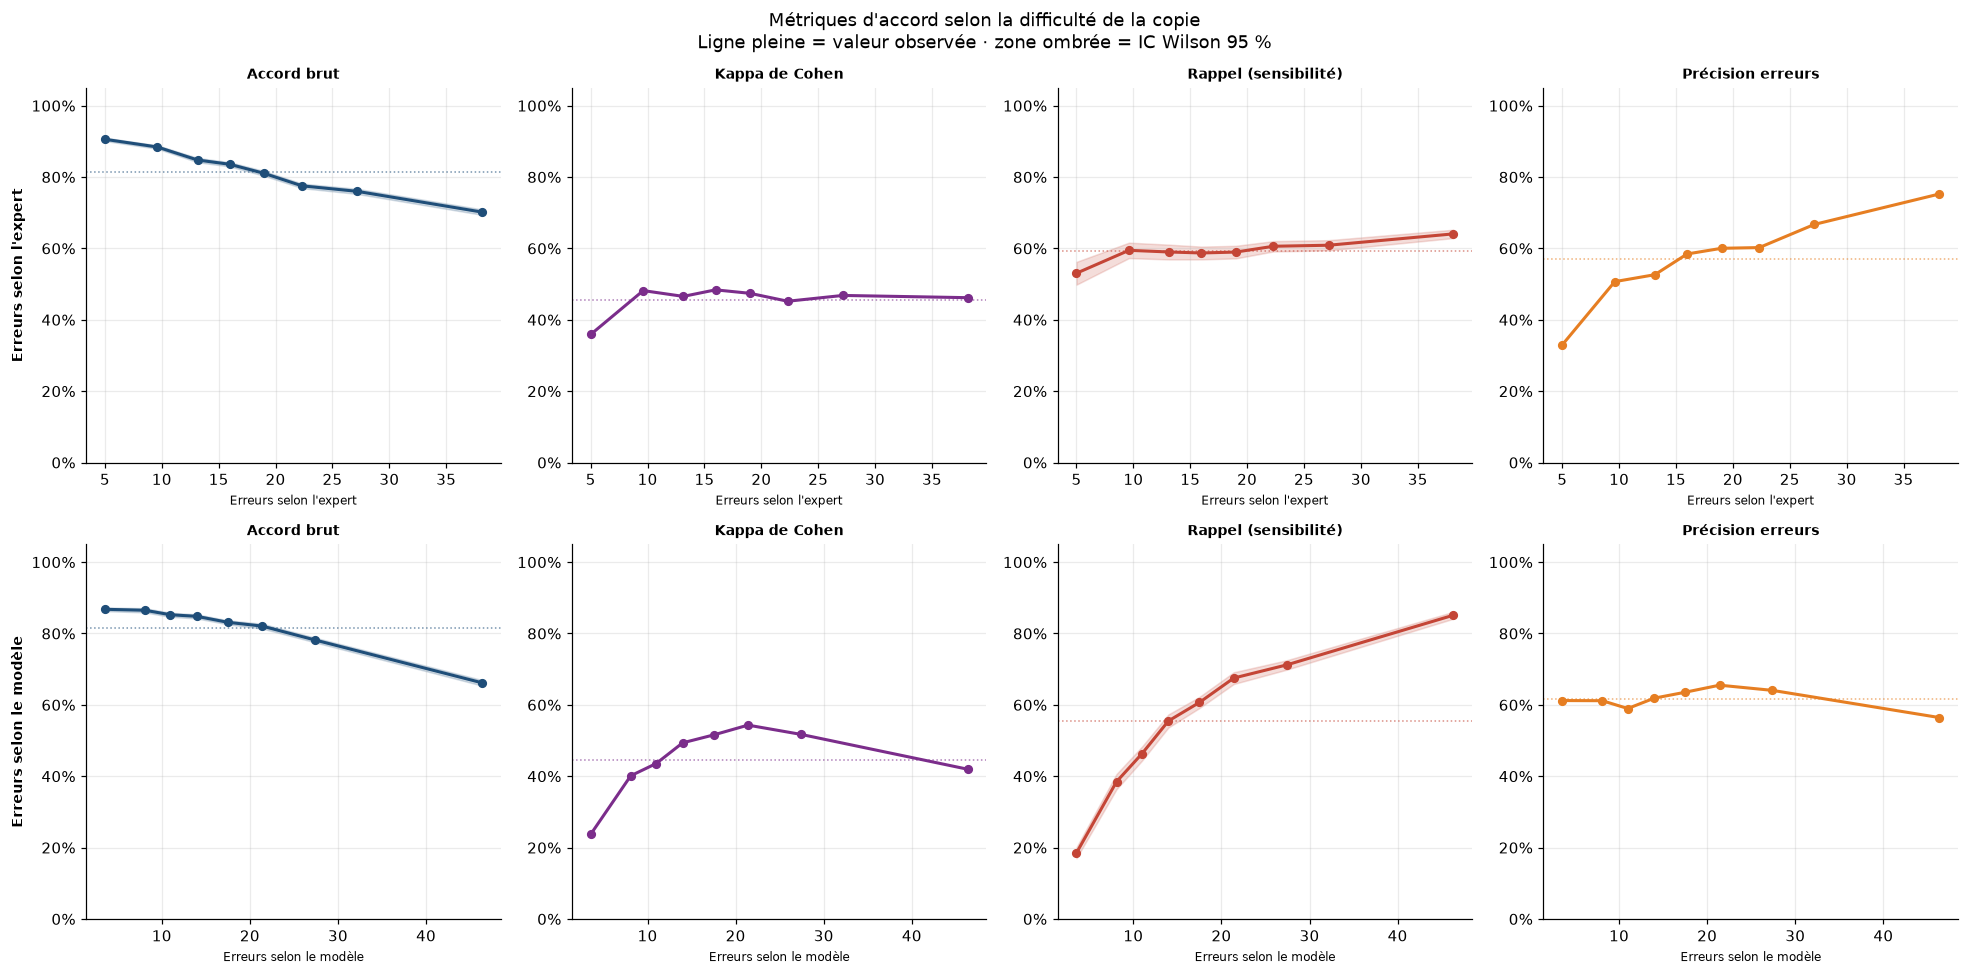

In [27]:
N_QUANTILES = 8

def metriques_par_groupe(df_items, copies_df, col_tri, n_q=N_QUANTILES):
    try:
        quantiles = pd.qcut(copies_df[col_tri], q=n_q, duplicates='drop')
    except ValueError:
        quantiles = pd.cut(copies_df[col_tri], bins=n_q, duplicates='drop')
    copies_df = copies_df.copy(); copies_df['_g'] = quantiles
    mid_x = copies_df.groupby('_g', observed=True)[col_tri].mean()
    rows = []
    for grp_label, grp_copies in copies_df.groupby('_g', observed=True):
        sub = df_items[df_items['copy_id'].isin(grp_copies.index)]
        if len(sub) < 10: continue
        n = len(sub); n_acc = int((sub['y_true'] == sub['y_pred']).sum())
        exp_e = sub['y_true'] != '1'; mod_e = sub['y_pred'] != '1'
        n_vp = int((exp_e & mod_e).sum()); n_ee = int(exp_e.sum()); n_me = int(mod_e.sum())
        _, acc_lo, acc_hi = wilson_global(n_acc, n)
        _, rap_lo, rap_hi = wilson_global(n_vp, n_ee) if n_ee else (float('nan'),) * 3
        try: kap = cohen_kappa_score(sub['y_true'], sub['y_pred'])
        except Exception: kap = float('nan')
        rows.append({'x': mid_x[grp_label], 'n_copies': len(grp_copies),
                     'accord': n_acc / n, 'acc_lo': acc_lo, 'acc_hi': acc_hi,
                     'kappa': kap, 'rappel': (n_vp / n_ee) if n_ee else float('nan'),
                     'rap_lo': rap_lo, 'rap_hi': rap_hi,
                     'precision': (n_vp / n_me) if n_me else float('nan')})
    return pd.DataFrame(rows).sort_values('x')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Métriques d'accord selon la difficulté de la copie\n"
             "Ligne pleine = valeur observée · zone ombrée = IC Wilson 95 %", fontsize=12)

SOURCES = [('n_erreurs_expert', "Erreurs selon l'expert"),
           ('n_erreurs_modele', "Erreurs selon le modèle")]
METRIQUES = [('accord', 'Accord brut', 'acc_lo', 'acc_hi', C_EXPERT),
             ('kappa', 'Kappa de Cohen', None, None, '#7b2d8b'),
             ('rappel', 'Rappel (sensibilité)', 'rap_lo', 'rap_hi', C_MODELE),
             ('precision', 'Précision erreurs', None, None, '#e67e22')]

for col_idx, (col_tri, label_tri) in enumerate(SOURCES):
    g = metriques_par_groupe(df, copies_m, col_tri)
    xs = g['x'].values
    for row_idx, (metric, label, lo_col, hi_col, color) in enumerate(METRIQUES):
        ax = axes[col_idx][row_idx]
        ax.plot(xs, g[metric].values, color=color, lw=2, marker='o', ms=5)
        if lo_col and hi_col:
            ax.fill_between(xs, g[lo_col].values, g[hi_col].values, alpha=0.18, color=color)
        ax.axhline(g[metric].mean(), color=color, ls=':', lw=1, alpha=0.6)
        ax.set_title(label, fontsize=9, fontweight='bold')
        ax.set_xlabel(label_tri, fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    axes[col_idx][0].set_ylabel(label_tri, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_metriques_par_difficulte.png', bbox_inches='tight')
plt.show()


## 6. Comparaison multi-modèles (optionnelle)

**Motivation** : quand plusieurs modèles indépendants convergent, la
prédiction est fiable ; quand ils divergent, c'est un signal d'incertitude
qui appelle un humain. Le désaccord inter-modèles est un **bien meilleur
prédicteur de confiance** que le score annoncé par un modèle unique.

**Pré-requis** : avoir lancé plusieurs benchmarks sur les mêmes copies
(configs différentes : modèles ou prompts variés). Chaque run produit son
`<run>_predictions.jsonl`.

In [28]:
from evaluation_dictee.evaluation.multi_model import (
    agreement_per_item, confidence_score, disagreement_type_summary,
    load_multi_runs, referral_curve_with_ci,
)

# ═══════════ Sélection des runs à comparer ═══════════
RUNS_MULTI = [
    RUN_NAME,
    'dictee_qwen3-6-35b-moe_cot',
    #'dictee_qwen3vl_cot',
    #'dictee_gemma4_cot',
]
# ═════════════════════════════════════════════════════

RUNS_MULTI = [r for r in RUNS_MULTI
              if (BASE / f'data/processed/{r}_predictions.jsonl').exists()]
print(f'Runs disponibles : {RUNS_MULTI}')

if len(RUNS_MULTI) < 2:
    print('\n⚠️  Un seul run disponible.')
    print('   Pour la comparaison multi-modèles, lancer d\'autres benchmarks')
    print('   (ex. chain-of-thought, approche 2 étapes) et relancer.')
    df_agree = None; conf_copies = None
else:
    df_multi = load_multi_runs(RUNS_MULTI, output_dir=BASE / 'data/processed')
    df_agree = agreement_per_item(df_multi)
    conf_copies = confidence_score(df_agree)
    print(f'\n{len(df_multi):,} items × {len(RUNS_MULTI)} modèles')
    print(f'{df_agree["unanimite"].mean() * 100:.1f} % d\'items en unanimité')
    print(f'Score de confiance moyen par copie : {conf_copies["score_confiance"].mean():.1f} %')


Runs disponibles : ['dictee_gemma4_cot', 'dictee_qwen3-6-35b-moe_cot']

45,069 items × 2 modèles
82.0 % d'items en unanimité
Score de confiance moyen par copie : 82.0 %


Répartition des items selon le nb de modèles d'accord :



,n_items,pct_items,accord_avec_expert
n_accord_modeles,,,
1,8115,18.0 %,34.7 %
2,36954,82.0 %,92.4 %



Lecture : quand tous les modèles s'accordent (dernière ligne), l'accord
avec l'expert est élevé → le désaccord inter-modèles est prédictif d'erreur.


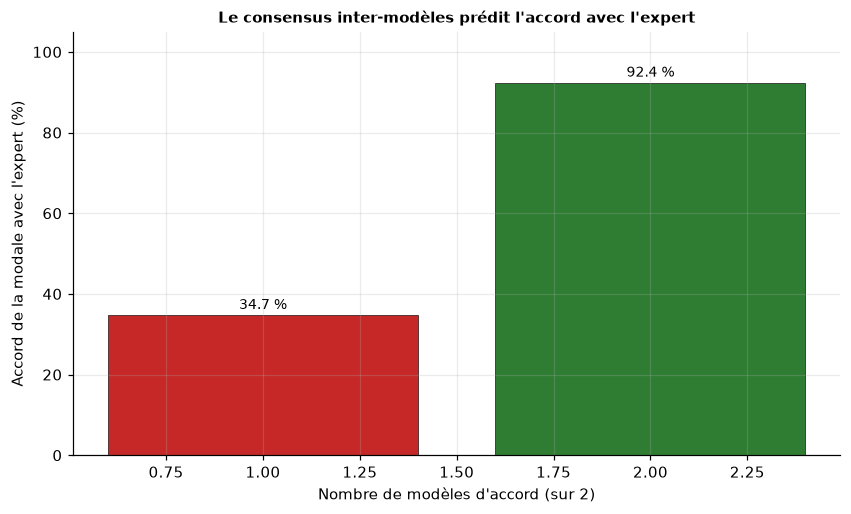

In [29]:
if df_agree is not None:
    summary = disagreement_type_summary(df_agree)
    print("Répartition des items selon le nb de modèles d'accord :\n")
    display(summary.style.format({'pct_items': '{:.1f} %', 'accord_avec_expert': '{:.1f} %'}))
    print("\nLecture : quand tous les modèles s'accordent (dernière ligne), l'accord")
    print("avec l'expert est élevé → le désaccord inter-modèles est prédictif d'erreur.")

    fig, ax = plt.subplots(figsize=(9, 5))
    couleurs = [C_PB if v < 70 else C_MOYEN if v < 90 else C_OK for v in summary['accord_avec_expert']]
    ax.bar(summary.index, summary['accord_avec_expert'], color=couleurs, edgecolor='k', linewidth=0.4)
    for idx, val in summary['accord_avec_expert'].items():
        ax.annotate(f'{val:.1f} %', (idx, val), textcoords='offset points',
                    xytext=(0, 4), ha='center', fontsize=9)
    ax.set_xlabel(f'Nombre de modèles d\'accord (sur {int(df_agree["n_modeles"].iloc[0])})')
    ax.set_ylabel("Accord de la modale avec l'expert (%)")
    ax.set_title("Le consensus inter-modèles prédit l'accord avec l'expert",
                 fontsize=10, fontweight='bold')
    ax.set_ylim(0, 105)
    plt.savefig(FIG_DIR / '06_consensus_predit_accord.png')
    plt.show()


## 7. Stratégie de renvoi basée sur le désaccord multi-modèles

**Question opérationnelle** : combien de copies faut-il renvoyer en
correction humaine pour atteindre un accord cible sur les copies retenues ?

**Stratégie** : trier les copies par score de confiance (% d'items où tous
les modèles s'accordent), renvoyer celles sous le seuil τ. **Un seul
graphique clair** : accord retenu en fonction du % renvoyé, avec IC Wilson
et repères aux seuils clés (10 %, 20 %, 30 %, 50 %).

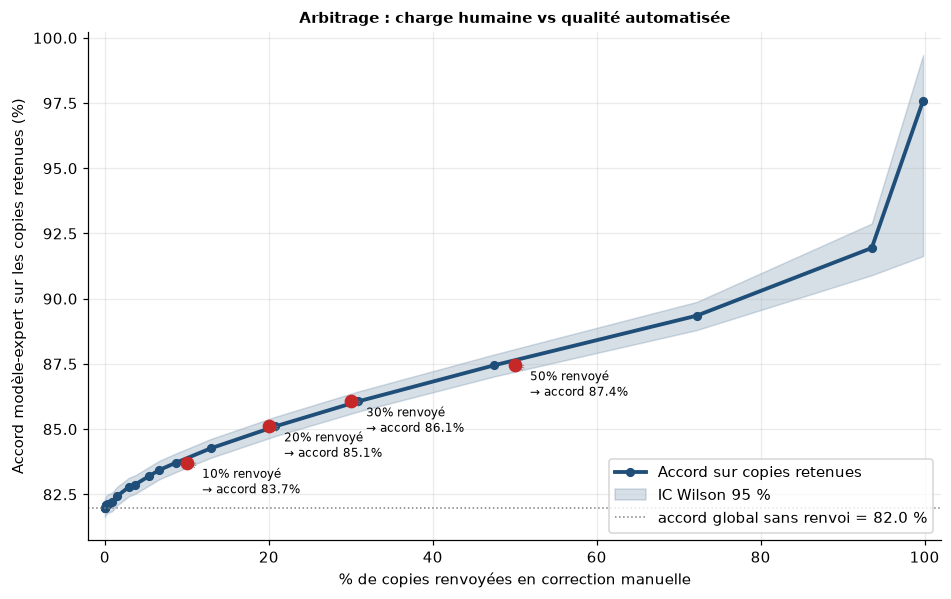


Seuils clés :


,seuil_confiance,pct_copies_renvoyees,pct_accord_retenues,accord_lo,accord_hi,n_copies_retenues,n_items_retenus
10,50,3.7 %,82.9 %,82.5 %,83.2 %,523,43409
12,60,6.6 %,83.4 %,83.1 %,83.8 %,507,42081
14,70,12.9 %,84.3 %,83.9 %,84.6 %,473,39259
16,80,30.9 %,86.1 %,85.7 %,86.4 %,375,31125
18,90,72.2 %,89.3 %,88.8 %,89.9 %,151,12533
19,95,93.6 %,91.9 %,90.9 %,92.9 %,35,2905
20,100,99.8 %,97.6 %,91.6 %,99.3 %,1,83


In [30]:
if df_agree is not None:
    curve = referral_curve_with_ci(df_agree, conf_copies, reference_run=RUN_NAME)

    fig, ax = plt.subplots(figsize=(10, 6))
    xs = curve['pct_copies_renvoyees'].values
    ys = curve['pct_accord_retenues'].values
    ax.plot(xs, ys, color=C_EXPERT, lw=2.5, marker='o', ms=5, label='Accord sur copies retenues')
    ax.fill_between(xs, curve['accord_lo'], curve['accord_hi'],
                    alpha=0.18, color=C_EXPERT, label='IC Wilson 95 %')
    ax.axhline(ys[0], color='grey', ls=':', lw=1,
               label=f'accord global sans renvoi = {ys[0]:.1f} %')

    # Repères aux seuils clés
    for pct_ref in [10, 20, 30, 50]:
        idx = (curve['pct_copies_renvoyees'] - pct_ref).abs().idxmin()
        acc_ref = curve.loc[idx, 'pct_accord_retenues']
        if not np.isnan(acc_ref):
            ax.plot(pct_ref, acc_ref, 'o', color='#c62828', ms=8, zorder=5)
            ax.annotate(f'{pct_ref}% renvoyé\n→ accord {acc_ref:.1f}%',
                        (pct_ref, acc_ref), textcoords='offset points', xytext=(10, -20),
                        fontsize=8, arrowprops=dict(arrowstyle='->', color='grey', lw=0.5))

    ax.set_xlabel('% de copies renvoyées en correction manuelle')
    ax.set_ylabel('Accord modèle-expert sur les copies retenues (%)')
    ax.set_title('Arbitrage : charge humaine vs qualité automatisée',
                 fontsize=10, fontweight='bold')
    ax.legend(loc='lower right'); ax.set_xlim(-2, 102)
    plt.savefig(FIG_DIR / '07_arbitrage_renvoi.png')
    plt.show()

    print('\nSeuils clés :')
    display(curve[curve['seuil_confiance'].isin([50, 60, 70, 80, 90, 95, 100])]
        .style.format({'pct_copies_renvoyees': '{:.1f} %',
                       'pct_accord_retenues': '{:.1f} %',
                       'accord_lo': '{:.1f} %', 'accord_hi': '{:.1f} %'}))


## 8. Décomposition des désaccords

In [31]:
deco = disagreement_decomposition(df)
display(deco.style.format({'pct_desaccords': '{:.1f} %'}))


,transition,n,pct_desaccords
0,expert:9 → modèle:1,9402,43.4 %
1,expert:1 → modèle:9,7484,34.5 %
2,expert:1 → modèle:0,2694,12.4 %
3,expert:0 → modèle:1,872,4.0 %
4,expert:9 → modèle:0,807,3.7 %
5,expert:0 → modèle:9,282,1.3 %
6,expert: → modèle:1,68,0.3 %
7,expert:i → modèle:1,35,0.2 %
8,expert:i → modèle:9,13,0.1 %
9,expert:1 → modèle:?,7,0.0 %


## 9. Accord par item, avec intervalles de Wilson

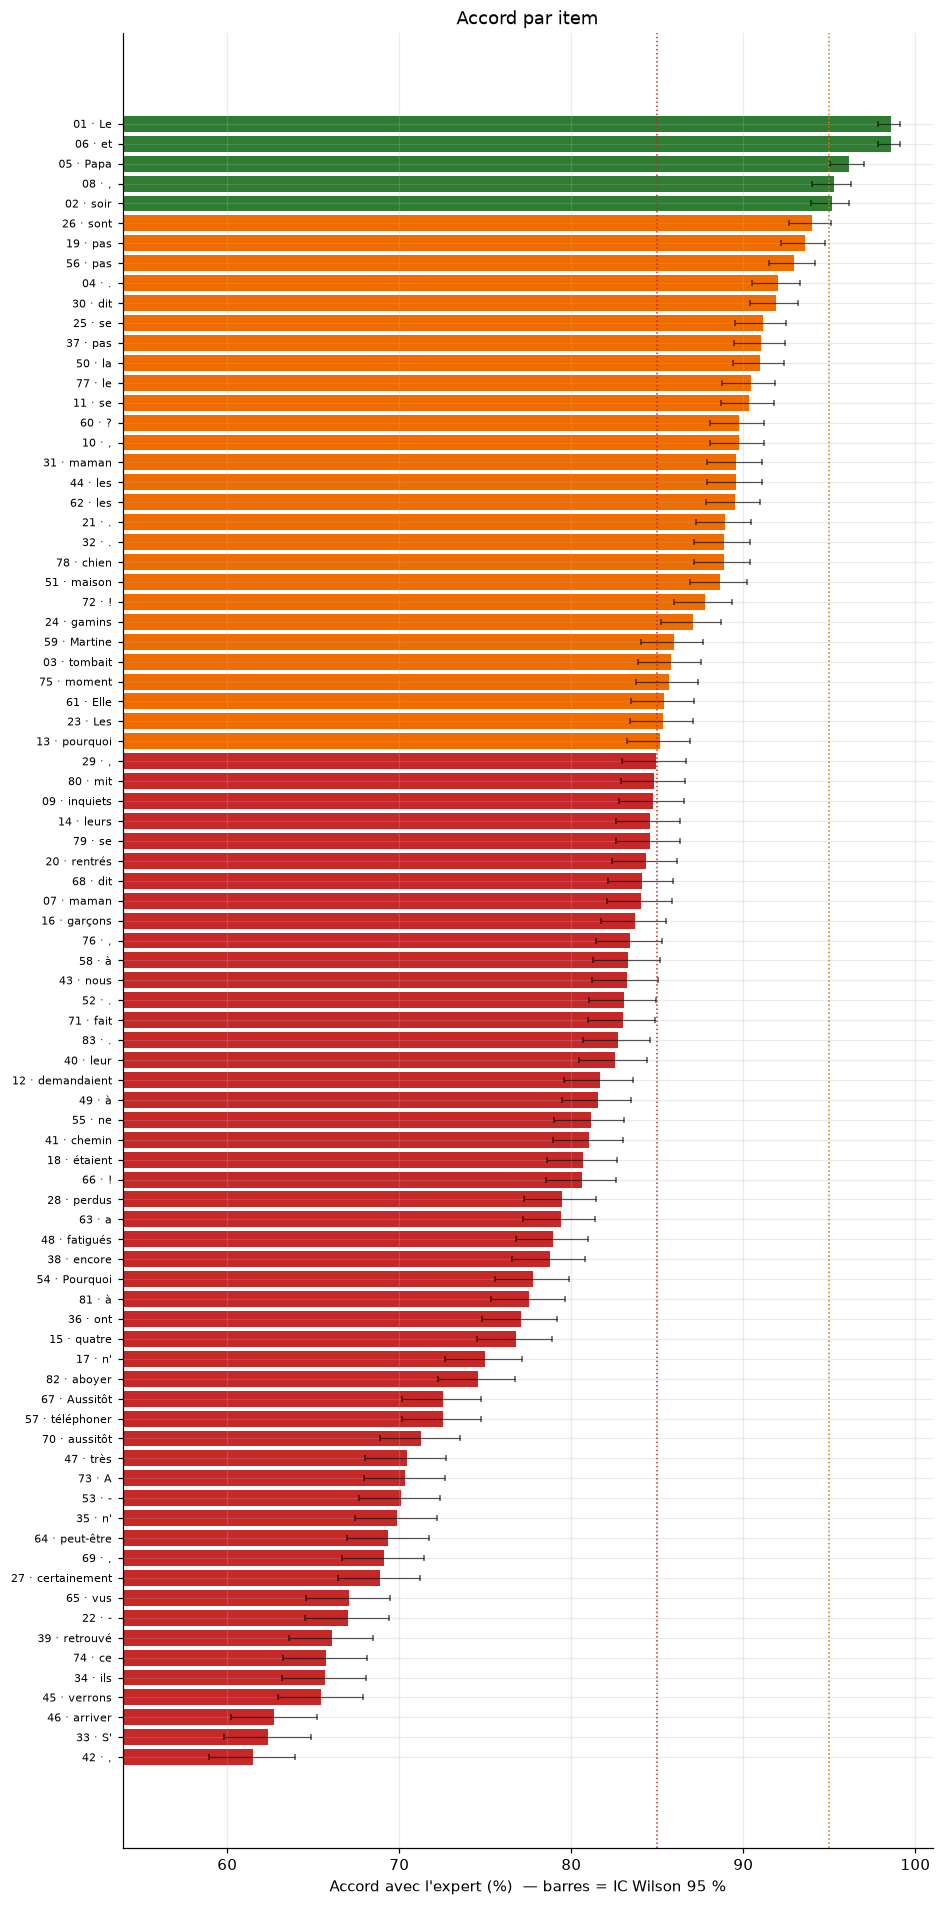

In [32]:
items = per_item_metrics(df); items_tries = items.sort_values('accord')
fig, ax = plt.subplots(figsize=(9.5, 0.24 * len(items_tries) + 1.5))
y = np.arange(len(items_tries))
couleurs = [C_PB if v < 0.85 else C_MOYEN if v < 0.95 else C_OK for v in items_tries['accord']]
err_low = (items_tries['accord'] - items_tries['accord_lo']) * 100
err_high = (items_tries['accord_hi'] - items_tries['accord']) * 100
ax.barh(y, items_tries['accord'] * 100, xerr=[err_low, err_high],
        color=couleurs, error_kw={'lw': 0.8, 'capsize': 2, 'alpha': 0.65})
ax.set_yticks(y); ax.set_yticklabels([lib(i) for i in items_tries.index], fontsize=7)
ax.axvline(85, color=C_PB, ls=':', lw=1); ax.axvline(95, color=C_MOYEN, ls=':', lw=1)
ax.set_xlim(max(0, items_tries['accord_lo'].min() * 100 - 5), 101)
ax.set_xlabel("Accord avec l'expert (%)  — barres = IC Wilson 95 %")
ax.set_title('Accord par item')
plt.savefig(FIG_DIR / '09_accord_par_item.png'); plt.show()


## 10. Accord par copie

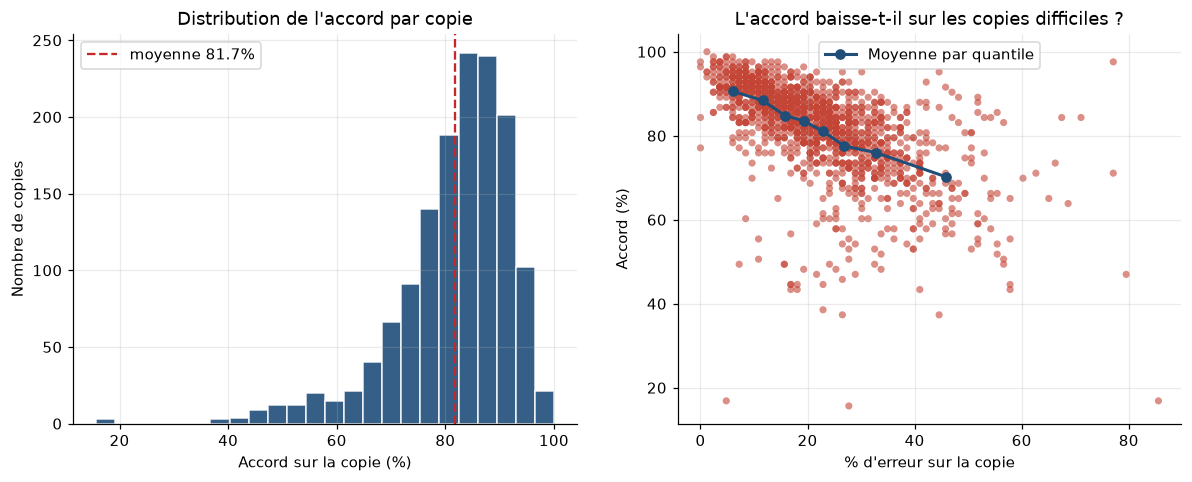

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.hist(copies_m['accord'] * 100, bins=24, color=C_EXPERT, edgecolor='white', alpha=0.9)
ax1.axvline(copies_m['accord'].mean() * 100, color=C_PB, ls='--',
            label=f"moyenne {copies_m['accord'].mean():.1%}")
ax1.set_xlabel('Accord sur la copie (%)'); ax1.set_ylabel('Nombre de copies')
ax1.set_title("Distribution de l'accord par copie"); ax1.legend()

ax2.scatter(copies_m['pct_erreur_expert'], copies_m['accord'] * 100,
            s=22, alpha=0.6, color=C_MODELE, edgecolors='none')
nq = min(8, copies_m['pct_erreur_expert'].nunique())
q = pd.qcut(copies_m['pct_erreur_expert'], q=nq, duplicates='drop')
tend = copies_m.groupby(q, observed=True).agg(x=('pct_erreur_expert', 'mean'), yacc=('accord', 'mean'))
ax2.plot(tend['x'], tend['yacc'] * 100, color=C_EXPERT, lw=2, marker='o', label='Moyenne par quantile')
ax2.set_xlabel("% d'erreur sur la copie"); ax2.set_ylabel('Accord (%)')
ax2.set_title("L'accord baisse-t-il sur les copies difficiles ?"); ax2.legend()
plt.savefig(FIG_DIR / '10_accord_par_copie.png')
plt.show()


## 11. Export HTML pour l'équipe DEPP — sélection des sections

In [34]:
from evaluation_dictee.evaluation.html_report import list_sections, build_html_report

NOTEBOOK_PATH = Path('03_analyse_resultats.ipynb')
for s in list_sections(NOTEBOOK_PATH):
    print(f'  {s.tag:35}  {s.title}')


  section:synthese                     1. Synthèse globale avec intervalles de confiance
  section:prevalence_item              2. Prévalence d'erreur par item — expert vs modèle
  section:distribution_erreurs         3. Distribution du nombre d'erreurs par copie
  section:correlation_niveau           4. Nombre d'erreurs modèle vs expert par copie
  section:metriques_par_difficulte     5. Métriques d'accord selon la difficulté de la copie
  section:multi_modeles                6. Comparaison multi-modèles (optionnelle)
  section:strategie_renvoi             7. Stratégie de renvoi basée sur le désaccord multi-modèles
  section:decomposition                8. Décomposition des désaccords
  section:accord_item                  9. Accord par item, avec intervalles de Wilson
  section:accord_copie                 10. Accord par copie
  section:exports                      11. Export HTML pour l'équipe DEPP — sélection des sections


/opt/python/lib/python3.13/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [35]:
SECTIONS_A_INCLURE = [
    'section:synthese', 'section:prevalence_item', 'section:distribution_erreurs',
    'section:correlation_niveau', 'section:metriques_par_difficulte',
    'section:multi_modeles', 'section:strategie_renvoi',
    'section:decomposition', 'section:accord_item', 'section:accord_copie',
]
out = build_html_report(
    notebook_path=NOTEBOOK_PATH, selected_tags=SECTIONS_A_INCLURE,
    output_path=BASE / f'data/processed/rapport_depp_{RUN_NAME}.html',
    hide_code=True, execute=False,
)
print(f'Rapport généré : {out}')


Rapport généré : ../data/processed/rapport_depp_dictee_gemma4_cot.html
